# Spotify Playlist Recommendation System
Muskan Bansal, Octavio Bittar, Logan Ranji, Mohammad Eissa, Ali Riad

Predicts whether a song will be **liked**, and which **playlists** it fits
(morning / afternoon / evening / late night / workout / chill), from one
person's Spotify listening history (Jan–Sep 2026, ~14.6k plays, ~4.9k songs)
plus song audio features from the [ReccoBeats API](https://reccobeats.com/docs/apis/reccobeats-api).

To begin, run the script below to create a new virtual environment and download requirements. **Then, make sure your Jupiter notebook is configured to use the .venv kernel.**

In [7]:
# Setup development environment (Windows CMD)
!python3 -m venv .venv && .\.venv\Scripts\activate.bat && pip install -r requirements.txt
!python -m ipykernel install --user --name=.venv --display-name="Python (.venv)"

# Setup development environment (Windows CMD)
# !python3 -m venv .venv && source .venv/bin/activate && pip install -r requirements.txt
# !python -m ipykernel install --user --name=myenv --display-name="Python (myenv)"

Unable to copy 'C:\\Users\\23the\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\venv\\scripts\\nt\\venvlauncher.exe' to 'c:\\Users\\23the\\Documents\\GitHub\\Machine-Learning-Team-Project\\.venv\\Scripts\\python.exe'


Installed kernelspec .venv in C:\Users\23the\AppData\Roaming\jupyter\kernels\.venv


## 1. Dataset
The first part of the project was obtaining **Spotify listening history** from one of our group members. This information can be requested from Spotify and downloaded within a few days. Next, `prepare_data.py` was used to process this data, keeping only the following statistics for each song in the history:
- ts (timestamp)
- ms_played
- track
- artist
- album
- track_uri (on Spotify)
- platform
- reason_start
- reason_end
- shuffle
- skipped
- offline

The useful data was saved in `plays.csv`

Then the following audio features are loaded from the ReccoBeats API for each track in the record. *Available for 73% of plays; missing values are left blank.
- energy
- danceability
- tempo
- valence
- acousticness
- instrumentalness
- speechiness
- liveness
- loudness
- key

Several other features are then inferred fromm each record, such as start and end times, weekday vs weekend plays, etc.
Most importantly, a song is determined to be **"liked" if it was listened for more than 30 seconds AND not skipped**.

In [8]:
# Run this line only you have a raw user history file from Spotify and need to parse it. plays.csv is already provided in the repo.
# python prepare_data.py path/to/Streaming_History_Audio_*.json#

import features
# load listening history
listening_history = features.load_plays();
print(f"Loaded {listening_history.shape[0]} song play records.")
print(f"Each record contains {listening_history.shape[1]} values.")
print(f"listening_history is: [{listening_history.shape[0]} x {listening_history.shape[1]}]")
# add track features
df = features.build_features(listening_history)
print(f"With the added features, df is: [{df.shape[0]} x {df.shape[1]}]")
# Uncomment to see the full list of features
# print(df.columns)
print(f"Liked rate: {df['liked'].mean():.1%}")


Loaded 14645 song play records.
Each record contains 12 values.
listening_history is: [14645 x 12]
With the added features, df is: [14645 x 44]
Liked rate: 44.5%


## 2. Training the Model

`train_model.py` trains a classifier model that predicts whether a song play will be liked by the user. Every feature comes from
what happened *before* that play, so the model can't cheat. Each training example has the following features: 
- the song and artist's past like ratio and play count (overall and at current time of day)
- time of day, weekday, device, shuffle, how the play started
- how the current listening session is going (was the last song liked? etc.)
- the song's 11 audio features
Each training example (x) is a vector of size 32, with a binary label (y) indicating if the model predicts if the song will be liked (1) or not (0).

### Data Split
The whole data set is split as such: tracks listened before 2026-08-01 are training examples (77.8%) and after that testing (22.2%).

In [9]:
import pandas as pd
from features import (AUDIO, CATEGORICAL, CONTEXTS, FEATURES, FEATURES_NO_AUDIO, NUMERIC,
                      build_features, load_plays, history_snapshot, load_audio_features)
# Separates testing set and training set
TEST_START = pd.Timestamp("2026-08-01", tz="UTC")
train, test = df[df["ts"] < TEST_START], df[df["ts"] >= TEST_START]
X_train, y_train = train[FEATURES], train["liked"]
X_test, y_test = test[FEATURES], test["liked"]
print(f"test set: {X_train.shape}")    
print(f"train set: {X_test.shape}")

test set: (11394, 32)
train set: (3251, 32)


### Building Models
A few different machine learning model types were explored for this classifier. These were selected as they are light-weight and fast for running locally on the background of user's mobile devices. The models compared were the following:
- Always guess "not liked" (algorithmic, baseline)
- Logistic regression (with and without audio features)
- Gradient boosting classifier (with and without audio features)
- Neural Network (with and without audio features)

In [10]:
import json
import time
from pathlib import Path
import numpy as np
import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

def gradient_boosting():
    encode = ColumnTransformer(
        [("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), CATEGORICAL)],
        remainder="passthrough",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")
    model = HistGradientBoostingClassifier(
        categorical_features=CATEGORICAL,
        learning_rate=0.05,
        max_iter=300,
        early_stopping=True,
        random_state=0,
    )
    return make_pipeline(encode, model)


def logistic_regression(features=FEATURES):
    numeric = [c for c in NUMERIC + AUDIO if c in features]
    encode = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ])
    return make_pipeline(encode, LogisticRegression(max_iter=1000))

def neural_network(features=FEATURES):
    numeric = [c for c in NUMERIC + AUDIO if c in features]
    encode = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ])
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-3,              # L2 regularization
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,     # holds out 10% of training data to stop when validation score plateaus
        n_iter_no_change=15,
        random_state=0,
    )
    return make_pipeline(encode, model)


models = {
    "baseline (always majority)": (DummyClassifier(strategy="most_frequent"), FEATURES),
    "logistic regression, no audio features": (logistic_regression(FEATURES_NO_AUDIO), FEATURES_NO_AUDIO),
    "logistic regression + audio features": (logistic_regression(), FEATURES),
    "gradient boosting, no audio features": (gradient_boosting(), FEATURES_NO_AUDIO),
    "gradient boosting + audio features": (gradient_boosting(), FEATURES),
    "neural network, no audio features": (neural_network(FEATURES_NO_AUDIO), FEATURES_NO_AUDIO),
    "neural network + audio features": (neural_network(), FEATURES),
}

### Training and Comparing Models
The seven models above are trained and tested for comparison and fine tuning.

                                        accuracy  precision  recall     f1  roc_auc  training_time
baseline (always majority)                 0.510      0.000   0.000  0.000    0.500          0.001
logistic regression, no audio features     0.752      0.744   0.755  0.749    0.835          0.038
logistic regression + audio features       0.752      0.741   0.759  0.750    0.837          0.058
gradient boosting, no audio features       0.750      0.752   0.731  0.741    0.828          0.312
gradient boosting + audio features         0.748      0.749   0.731  0.740    0.828          0.356
neural network, no audio features          0.755      0.753   0.744  0.749    0.838          0.780
neural network + audio features            0.755      0.749   0.753  0.751    0.832          0.821 



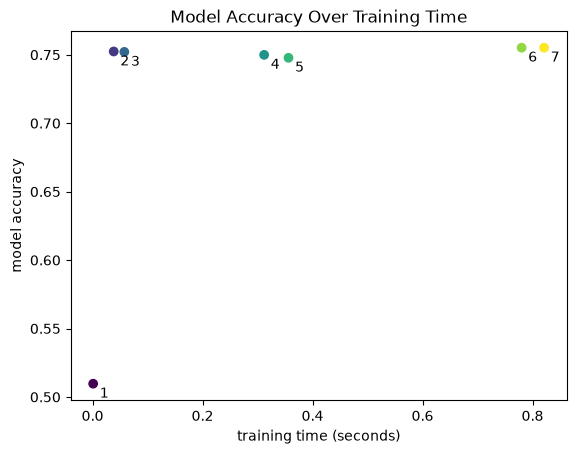

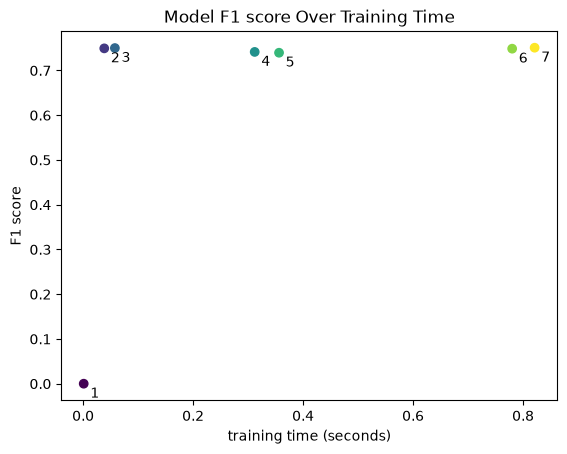

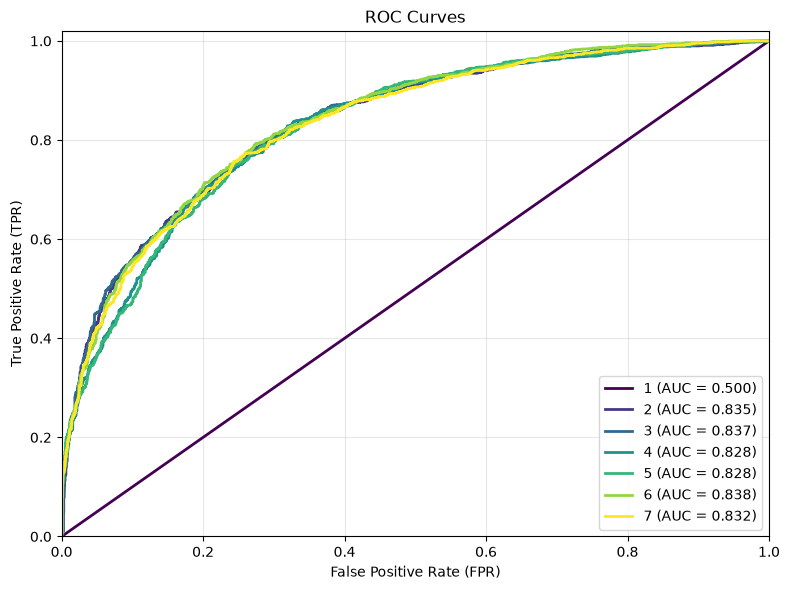

In [11]:
def scores(y, prob, training_time):
    pred = (prob >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, prob) if len(set(y)) > 1 else float("nan"),
        "training_time": training_time
    }

results = {}
for name, (model, features) in models.items():
    start_time = time.time()
    model.fit(X_train[features], y_train)
    end_time = time.time()
    results[name] = scores(y_test, model.predict_proba(X_test[features])[:, 1], end_time - start_time)
print(pd.DataFrame(results).T.round(3).to_string(), "\n")

# Graph: Analysis of accuracy over training time:
import matplotlib.pyplot as plt
x = pd.DataFrame(results).T["training_time"].tolist()
y = pd.DataFrame(results).T["accuracy"].tolist()
labels = range(7)
plt.scatter(x, y,  c=range(7), cmap='viridis')
for i, label in enumerate(labels):
    plt.annotate(
        label+1,
        (x[i], y[i]),
        textcoords="offset points",
        xytext=(8, -10),
        ha='center'
    )
plt.title("Model Accuracy Over Training Time")
plt.xlabel("training time (seconds)")
plt.ylabel("model accuracy")
plt.show()

# Graph: Analysis of f1 over training time:
x = pd.DataFrame(results).T["training_time"].tolist()
y = pd.DataFrame(results).T["f1"].tolist()
labels = range(7)
plt.scatter(x, y,  c=range(7), cmap='viridis')
for i, label in enumerate(labels):
    plt.annotate(
        label+1,
        (x[i], y[i]),
        textcoords="offset points",
        xytext=(8, -10),
        ha='center'
    )
plt.title("Model F1 score Over Training Time")
plt.xlabel("training time (seconds)")
plt.ylabel("F1 score")
plt.show()

# Graph: AUC curves:
from sklearn.metrics import roc_curve
colors = plt.cm.viridis(np.linspace(0, 1, n))
fig, ax = plt.subplots(figsize=(8, 6))
for i, (color, (name, (model, features))) in enumerate(zip(colors, models.items()), start=1):
    prob = model.predict_proba(X_test[features])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = results[name]["roc_auc"]
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{i} (AUC = {auc:.3f})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("ROC Curves")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Model Evaluation
All four models (except baseline) are nearly tied for performance. We can make the following conclusions:
- The song audio features only add extra complexity without improving the model, so they can be discarded.
- Simple logistic regression models are way faster to train, so they should be picked over boost classifier.

Thus, the model we pick is the logistic regression without audio features.
We can now test its performance on classifying songs based on different times (morning, afternoon, evening, late_night).

In [12]:
from requests.utils import _null


best = models["logistic regression, no audio features"][0]
prob = best.predict_proba(X_test)[:, 1]
by_context = {ctx: scores(y_test[test["context"] == ctx], prob[test["context"] == ctx], _null)
                for ctx in CONTEXTS}
print("Logistic regression (without audio features), test set by playlist context (times of day):")
print(pd.DataFrame(by_context).T.round(3).to_string(), "\n")

# Refit model with only the liked songs for deployment:
final = logistic_regression(FEATURES_NO_AUDIO).fit(df[FEATURES_NO_AUDIO], df["liked"])
Path("models").mkdir(exist_ok=True)
joblib.dump(final, "models/like_model.joblib") # save to models/like_model.joblib

Logistic regression (without audio features), test set by playlist context (times of day):
            accuracy precision    recall        f1   roc_auc training_time
morning     0.716854  0.757246  0.779851  0.768382  0.799034       b'\x00'
afternoon   0.768585  0.742466  0.732432  0.737415  0.846878       b'\x00'
evening     0.676887  0.668258  0.674699  0.671463  0.758085       b'\x00'
late_night  0.811388  0.794275  0.820702  0.807273  0.887468       b'\x00' 



['models/like_model.joblib']

## 3. Recommending Playlists
For each song with 3+ plays, the logistic regression model scores it at 100 real listening (times) from each time of day and averages the results. 
A song:
- is **liked** if its overall probability score is ≥ 0.5
- **fits a playlist** if the score is at least 5 points more than a typical song at that time of day (morning, afternoon, evening, late-night)

Each playlist is ordered by how much more the song is liked at that time than at other times, so the four playlists don't just repeat the same favorites.

Additional playlist categorization:
Although the audio features were not used for the like-prediction model, they can still be used to take recommended songs and split them into playlists of different styles. For example, we built the **Workout** and **Chill** playlists based on rules from the audio features, because there's no record/data of when you were working out to learn from. Thus, recommendations are built by taking the predicted-liked songs and checking the following:
- Workout: energy ≥ 0.65, danceability ≥ 0.6, tempo ≥ 100 BPM
- Chill: energy ≤ 0.45, acousticness ≥ 0.4

In [13]:
MIN_PLAYS = 3          # songs heard fewer times than this are too unknown to judge
LIKED_THRESHOLD = 0.5
FIT_MARGIN = 0.05
PLAYLIST_SIZE = 50
MOMENTS_PER_CONTEXT = 100

# Sound-based playlists: (feature, ">=" or "<=", threshold) rules a liked song must all meet.
SOUND_PLAYLISTS = {
    "workout": [("energy", ">=", 0.65), ("danceability", ">=", 0.6), ("tempo", ">=", 100)],
    "chill": [("energy", "<=", 0.45), ("acousticness", ">=", 0.4)],
}

# Features describing the listening moment rather than the song.
MOMENT_COLS = [
    "context", "hour", "weekday", "is_weekend", "platform", "reason_start",
    "shuffle", "offline", "session_pos", "session_like_rate", "prev_liked", "gap_min",
]


def candidate_rows(plays, tracks):
    snap = history_snapshot(plays)
    moments = pd.concat([
        plays.loc[plays["context"] == ctx, MOMENT_COLS].sample(MOMENTS_PER_CONTEXT, random_state=0)
        for ctx in CONTEXTS
    ])
    rows = tracks[["track_uri", "artist"]].merge(moments, how="cross")

    rows = rows.join(snap["track"], on="track_uri").join(snap["artist"], on="artist")
    rows = rows.join(snap["track_ctx"], on=["track_uri", "context"])
    rows = rows.join(snap["artist_ctx"], on=["artist", "context"])
    rows = rows.join(snap["days_since_first_play"], on="track_uri")
    rows = rows.join(load_audio_features(), on="track_uri")
    # Never heard in this context yet -> zero plays, neutral rate.
    for name in ("track_ctx", "artist_ctx"):
        rows[f"{name}_prev_plays"] = rows[f"{name}_prev_plays"].fillna(0)
        rows[f"{name}_like_rate"] = rows[f"{name}_like_rate"].fillna(0.5)
    return rows


def matches(songs, rules):
    ok = pd.Series(True, index=songs.index)
    for feature, op, threshold in rules:
        ok &= songs[feature] >= threshold if op == ">=" else songs[feature] <= threshold
    return ok  # NaN audio (song not in ReccoBeats data) never matches



model = joblib.load("models/like_model.joblib")
plays = build_features(load_plays())

tracks = (plays.groupby("track_uri")
            .agg(track=("track", "first"), artist=("artist", "first"),
                plays=("liked", "size"), past_like_rate=("liked", "mean"))
            .reset_index())
tracks = tracks[tracks["plays"] >= MIN_PLAYS]

rows = candidate_rows(plays, tracks)
rows["p"] = model.predict_proba(rows[FEATURES])[:, 1]
p = rows.groupby(["track_uri", "context"])["p"].mean().unstack()[list(CONTEXTS)]

out = tracks.set_index("track_uri")
# Overall chance of liking it, weighting each context by how much you listen then.
context_share = plays["context"].value_counts(normalize=True)[list(CONTEXTS)]
out["p_liked"] = (p * context_share).sum(axis=1)
out["liked"] = out["p_liked"] >= LIKED_THRESHOLD
context_like_rate = plays.groupby("context")["liked"].mean()[list(CONTEXTS)]
lift = p - context_like_rate  # how much better than a typical song at that time
for ctx in CONTEXTS:
    out[f"p_{ctx}"] = p[ctx]
    out[f"fits_{ctx}"] = p[ctx] >= context_like_rate[ctx] + FIT_MARGIN
out = out.join(load_audio_features())
for name, rules in SOUND_PLAYLISTS.items():
    out[f"fits_{name}"] = out["liked"] & matches(out, rules)
out = out.sort_values("p_liked", ascending=False).round(3)

Path("outputs/playlists").mkdir(parents=True, exist_ok=True)
out.to_csv("outputs/track_predictions.csv")
print(f"Scored {len(out):,} songs with {MIN_PLAYS}+ plays: "
        f"{out['liked'].sum():,} predicted liked.\n")

for ctx in CONTEXTS:
    fits = out[out[f"fits_{ctx}"]]
    preference = lift.loc[fits.index, ctx] - lift.loc[fits.index].mean(axis=1)
    playlist = (fits.assign(preference=preference.round(3))
                .sort_values("preference", ascending=False)
                .head(PLAYLIST_SIZE)[["track", "artist", f"p_{ctx}", "preference"]])
    playlist.to_csv(f"outputs/playlists/{ctx}.csv")
    print(f"{ctx.replace('_', ' ').title()} playlist: "
            f"{out[f'fits_{ctx}'].sum():,} songs fit, top 5:")
    print(playlist.head(5).to_string(index=False), "\n")

for name, rules in SOUND_PLAYLISTS.items():
    rule_cols = [feature for feature, _, _ in rules]
    playlist = out[out[f"fits_{name}"]].head(PLAYLIST_SIZE)[["track", "artist", "p_liked", *rule_cols]]
    playlist.to_csv(f"outputs/playlists/{name}.csv")
    print(f"{name.title()} playlist: {out[f'fits_{name}'].sum():,} liked songs match, top 5:")
    print(playlist.head(5).to_string(index=False), "\n")
print("Wrote outputs/track_predictions.csv and outputs/playlists/*.csv")


Scored 1,528 songs with 3+ plays: 527 predicted liked.

Morning playlist: 754 songs fit, top 5:
         track               artist  p_morning  preference
          Skin              Rihanna      0.726       0.115
Just A Lil Bit              50 Cent      0.653       0.110
    All For Me Mariah the Scientist      0.729       0.084
    I'm On One            DJ Khaled      0.679       0.081
           TBH        PARTYNEXTDOOR      0.655       0.070 

Afternoon playlist: 538 songs fit, top 5:
           track               artist  p_afternoon  preference
      All For Me Mariah the Scientist        0.586       0.097
Who Could It Be?               cortex        0.805       0.060
       Attention               cortex        0.782       0.045
         To Fall          Jacob Watty        0.695       0.039
  on one tonight                Gunna        0.562       0.034 

Evening playlist: 622 songs fit, top 5:
                    track         artist  p_evening  preference
               I'm On 